# AISC'26 — Tiki Commerce Intelligence
## Current EDA + Taxonomy & Peer Audit

**Mục tiêu notebook này:** làm lại EDA trên **dữ liệu đã được pipeline hiện tại làm sạch và gán taxonomy**, thay vì tiếp tục dùng các biểu đồ raw-data cũ.

Notebook tập trung vào các câu hỏi trực tiếp phục vụ solution hiện tại:

1. Dữ liệu clean hiện tại có đặc điểm gì quan trọng cho bài toán reference-sales?
2. Taxonomy đang phân bố thế nào? Bao nhiêu sản phẩm được gán bằng rule và bao nhiêu phải fallback?
3. Product type nào đang phụ thuộc fallback nhiều nhất?
4. Taxonomy độc lập (holdout) có thực sự tổng quát tốt không?
5. Peer groups có đủ và đủ giống nhau không? Product type nào tạo peer kém?
6. Sales khác nhau thế nào giữa các product type — có đủ lý do để tránh global sales threshold không?
7. Các tín hiệu listing như ảnh/video có association mô tả nào đáng chú ý không? (**không suy diễn nhân quả**)

> **Quan trọng:** các biểu đồ về taxonomy/peer trong notebook này dùng output mới của repo (`data/processed/*`). Các file review độc lập chỉ được dùng để **đánh giá** sau khi review xong; không dùng holdout để sửa rule.

## Deliverables của task này

Sau khi chạy notebook, mục tiêu là có:

- `ml/reports/figures/*.png`: toàn bộ hình EDA để dùng cho report/poster sau này.
- `ml/reports/figures/eda_audit_summary.json`: các số liệu chính có thể trích vào report.
- `ml/reports/figures/*.csv`: bảng audit quan trọng (fallback, peer quality, holdout errors nếu có).
- Một checklist kết luận: **giữ / sửa / cần review thêm** cho taxonomy và peer groups.

### Checklist công việc của Nhung

- [ ] Chạy EDA trên `clean_products.csv`, không dùng raw 41,603 rows làm current result.
- [ ] Kiểm tra inventory taxonomy: explicit rules, fallback labels, observed labels.
- [ ] Kiểm tra `taxonomy_source` và fallback concentration.
- [ ] Kiểm tra independent holdout nếu review đã hoàn thành.
- [ ] Error analysis taxonomy theo source và product type.
- [ ] Kiểm tra peer coverage, mean similarity, insufficient-data reasons.
- [ ] Kiểm tra peer manual review nếu đã hoàn thành.
- [ ] Làm fresh sales EDA theo normalized `product_type`.
- [ ] Làm fresh image/video EDA để hỗ trợ recommendation, nhưng chỉ mô tả association.
- [ ] Xuất hình + summary để commit lên GitHub.

In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 120)

# Notebook được thiết kế để đặt trong ml/notebooks/ hoặc chạy từ repo root.
def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'ml' / 'config' / 'taxonomy.yml').exists() and (p / 'README.md').exists():
            return p
    raise FileNotFoundError(
        'Không tìm thấy repo root. Hãy mở notebook từ trong j4f-commerce-intelligence/'
    )

ROOT = find_repo_root()
PROCESSED = ROOT / 'data' / 'processed'
REVIEW_DIR = PROCESSED / 'review_queues'
FIGURE_DIR = ROOT / 'ml' / 'artifacts' / 'eda'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root:', ROOT)
print('EDA artifacts:', FIGURE_DIR)

Repo root: /Users/nhung/Documents/j4f-commerce-intelligence
EDA artifacts: /Users/nhung/Documents/j4f-commerce-intelligence/ml/artifacts/eda


In [2]:
# ---------- Helpers ----------
def read_csv_if_exists(path, **kwargs):
    path = Path(path)
    if not path.exists():
        print(f'[skip] Không có file: {path.relative_to(ROOT) if ROOT in path.parents else path}')
        return None
    return pd.read_csv(path, low_memory=False, **kwargs)

def read_json_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding='utf-8'))

def savefig(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('saved ->', path.relative_to(ROOT))
    plt.show()
    plt.close()

def pct(x):
    return f'{100*x:.2f}%'

def safe_bool(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.strip().str.lower().isin({'true','1','yes','y','đúng'})

clean_path = PROCESSED / 'clean_products.csv'
if not clean_path.exists():
    raise FileNotFoundError(
        'Thiếu data/processed/clean_products.csv. Chạy trước: python3 -m ml.src.cli prepare'
    )

clean = pd.read_csv(clean_path, low_memory=False)
peer = read_csv_if_exists(PROCESSED / 'peer_features.csv')
scores = read_csv_if_exists(PROCESSED / 'product_scores.csv')

print(f'clean: {clean.shape}')
if peer is not None: print(f'peer_features: {peer.shape}')
if scores is not None: print(f'product_scores: {scores.shape}')

[skip] Không có file: data/processed/product_scores.csv
clean: (41576, 24)
peer_features: (41576, 42)


# 1. Current clean-data snapshot

Mục này xác nhận notebook đang làm trên **output hiện tại của pipeline**, đồng thời tạo vài chỉ số đủ dùng cho phần data overview. Không cần làm lại toàn bộ missing-value EDA cũ nếu pipeline đã kiểm tra và chuẩn hóa.

In [3]:
required = [
    'product_id','product_name','seller_id','brand','category_raw','product_type',
    'price','discount_rate','rating_average','review_count','quantity_sold',
    'has_video','image_count','description_length','valid_for_model'
]
missing_required = [c for c in required if c not in clean.columns]
print('Missing expected columns:', missing_required or 'None')

snapshot = {
    'clean_rows': int(len(clean)),
    'unique_product_ids': int(clean['product_id'].astype(str).nunique()),
    'seller_count': int(clean['seller_id'].astype(str).nunique()) if 'seller_id' in clean else None,
    'product_type_count_observed': int(clean['product_type'].nunique(dropna=True)),
    'raw_category_count': int(clean['category_raw'].nunique(dropna=True)),
    'valid_for_model_rows': int(safe_bool(clean['valid_for_model']).sum()) if 'valid_for_model' in clean else None,
    'zero_sales_rate': float(clean['quantity_sold'].eq(0).mean()),
    'median_sales': float(clean['quantity_sold'].median()),
    'mean_sales': float(clean['quantity_sold'].mean()),
    'max_sales': float(clean['quantity_sold'].max()),
}
pd.Series(snapshot, name='value').to_frame()

Missing expected columns: None


,value
clean_rows,41576.000000
unique_product_ids,41576.000000
seller_count,3807.000000
product_type_count_observed,58.000000
raw_category_count,155.000000
valid_for_model_rows,41575.000000
zero_sales_rate,0.518280
median_sales,0.000000
mean_sales,17.776939
max_sales,24847.000000


# 2. Sales shape — fresh on cleaned data

**Lý do có giá trị:** nếu sales zero-inflated và long-tail, dùng một ngưỡng `quantity_sold` toàn cục để gắn “tốt/kém” sẽ thiếu công bằng giữa các nhóm sản phẩm. Đây là justification trực tiếp cho contextual comparison + reference sales.

saved -> ml/artifacts/eda/01_sales_distribution_log.png


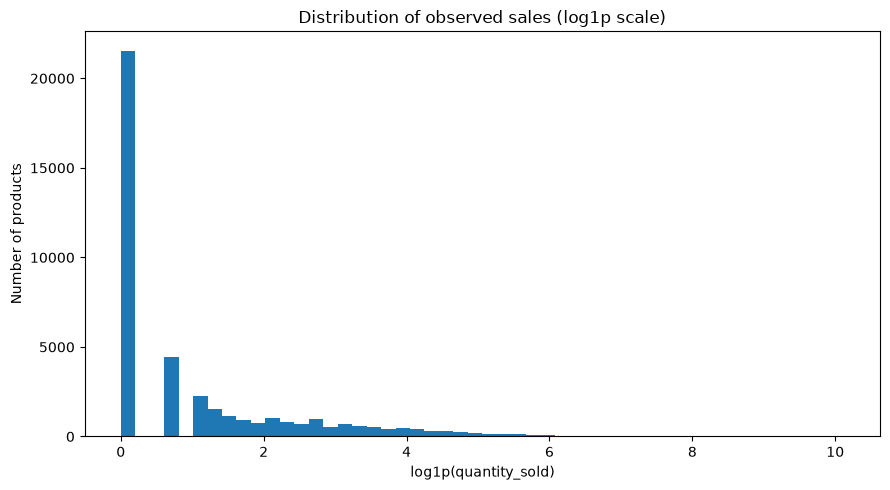

In [4]:
sales = pd.to_numeric(clean['quantity_sold'], errors='coerce').fillna(0).clip(lower=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(np.log1p(sales), bins=50)
ax.set_title('Distribution of observed sales (log1p scale)')
ax.set_xlabel('log1p(quantity_sold)')
ax.set_ylabel('Number of products')
savefig('01_sales_distribution_log.png')

saved -> ml/artifacts/eda/02_sales_concentration_pareto.png


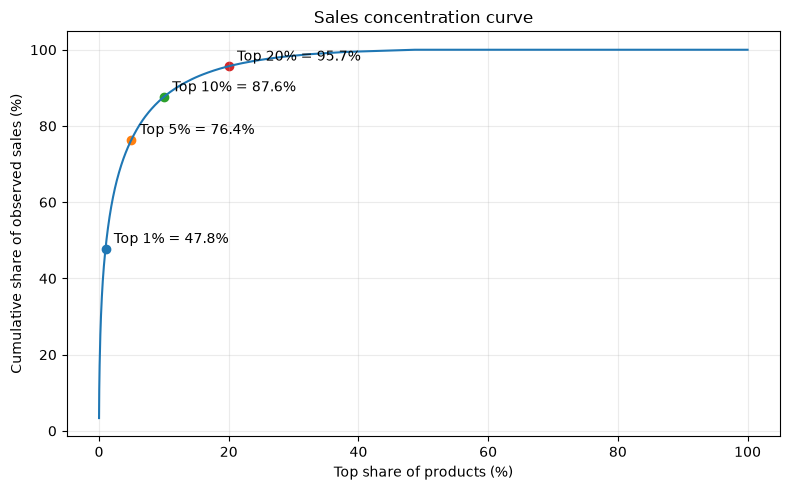

{'top_1pct_sales_share': 0.4782977537363312,
 'top_5pct_sales_share': 0.76428708662227,
 'top_10pct_sales_share': 0.8764040839189602,
 'top_20pct_sales_share': 0.9568309308423556}

In [5]:
# Pareto / concentration curve
ordered = sales.sort_values(ascending=False).reset_index(drop=True)
cum_share = ordered.cumsum() / max(ordered.sum(), 1)
x = (np.arange(len(ordered)) + 1) / len(ordered)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x * 100, cum_share * 100)
ax.set_title('Sales concentration curve')
ax.set_xlabel('Top share of products (%)')
ax.set_ylabel('Cumulative share of observed sales (%)')
ax.grid(alpha=.25)
for q in [1, 5, 10, 20]:
    idx = max(0, math.ceil(len(ordered) * q / 100) - 1)
    y = float(cum_share.iloc[idx] * 100)
    ax.scatter([q], [y])
    ax.annotate(f'Top {q}% = {y:.1f}%', (q, y), xytext=(6, 4), textcoords='offset points')
savefig('02_sales_concentration_pareto.png')

concentration = {}
for q in [1,5,10,20]:
    n = max(1, math.ceil(len(ordered) * q / 100))
    concentration[f'top_{q}pct_sales_share'] = float(ordered.iloc[:n].sum()/max(ordered.sum(),1))
concentration

# 3. Taxonomy configuration audit

Mục này tách ba khái niệm để tránh báo cáo nhầm:

- **Explicit rule labels**: nhãn định nghĩa trong `product_types`.
- **Fallback labels**: nhãn rộng dùng khi keyword rules không match.
- **Observed labels**: nhãn thực sự xuất hiện trong `clean_products.csv`.

Không nên nói “taxonomy có N nhãn” nếu chưa nói rõ N là loại nào.

In [6]:
taxonomy_path = ROOT / 'ml' / 'config' / 'taxonomy.yml'
config_path = ROOT / 'ml' / 'config' / 'pipeline.yml'

tax_cfg = yaml.safe_load(taxonomy_path.read_text(encoding='utf-8'))
pipe_cfg = yaml.safe_load(config_path.read_text(encoding='utf-8'))

rule_labels = [r['label'] for r in tax_cfg.get('product_types', [])]
fallback_map = tax_cfg.get('source_fallbacks', {})
fallback_labels = list(fallback_map.values())
observed_labels = sorted(clean['product_type'].dropna().astype(str).unique())

inventory = pd.DataFrame({
    'metric': [
        'explicit_rule_labels', 'unique_fallback_labels', 'possible_output_labels_union',
        'observed_labels_in_clean_data', 'fallback_labels_not_in_explicit_rules',
        'minimum_mean_peer_similarity_config'
    ],
    'value': [
        len(set(rule_labels)), len(set(fallback_labels)), len(set(rule_labels) | set(fallback_labels)),
        len(observed_labels), len(set(fallback_labels) - set(rule_labels)),
        pipe_cfg.get('minimum_mean_peer_similarity')
    ]
})
display(inventory)
print('Fallback-only labels:', sorted(set(fallback_labels) - set(rule_labels)))

pd.DataFrame({'product_type': sorted(set(rule_labels)|set(fallback_labels))}).to_csv(
    FIGURE_DIR / 'taxonomy_possible_labels.csv', index=False
)

,metric,value
0,explicit_rule_labels,53.00
1,unique_fallback_labels,6.00
2,possible_output_labels_union,58.00
3,observed_labels_in_clean_data,58.00
4,fallback_labels_not_in_explicit_rules,5.00
5,minimum_mean_peer_similarity_config,0.05


Fallback-only labels: ['balo vali túi khác', 'giày dép nam khác', 'giày dép nữ khác', 'túi ví nam khác', 'túi ví nữ khác']


### Audit point cần ghi vào report

Nếu số **observed labels**, **explicit rule labels** và **possible output labels** khác nhau thì đây không mặc định là bug. Nhưng report phải dùng đúng definition để không tạo version drift.

# 4. Taxonomy source & fallback concentration

**Đây là phần quan trọng nhất của taxonomy EDA.** Coverage 100% có thể đạt nhờ fallback, vì vậy cần nhìn thêm tỷ lệ gán bằng rule và fallback nằm ở đâu.

saved -> ml/artifacts/eda/03_taxonomy_source_overall.png


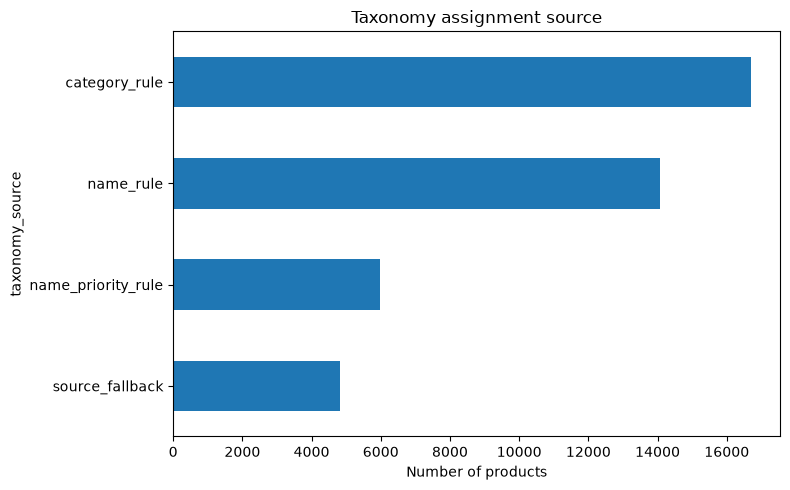

In [7]:
if 'taxonomy_source' not in clean.columns:
    raise KeyError('clean_products.csv hiện không có taxonomy_source — cần rerun prepare bằng code mới.')

source_counts = clean['taxonomy_source'].fillna('missing').value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
source_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Taxonomy assignment source')
ax.set_xlabel('Number of products')
ax.set_ylabel('taxonomy_source')
savefig('03_taxonomy_source_overall.png')

source_counts.to_csv(FIGURE_DIR / 'taxonomy_source_counts.csv', header=['count'])

saved -> ml/artifacts/eda/04_product_type_top_counts.png


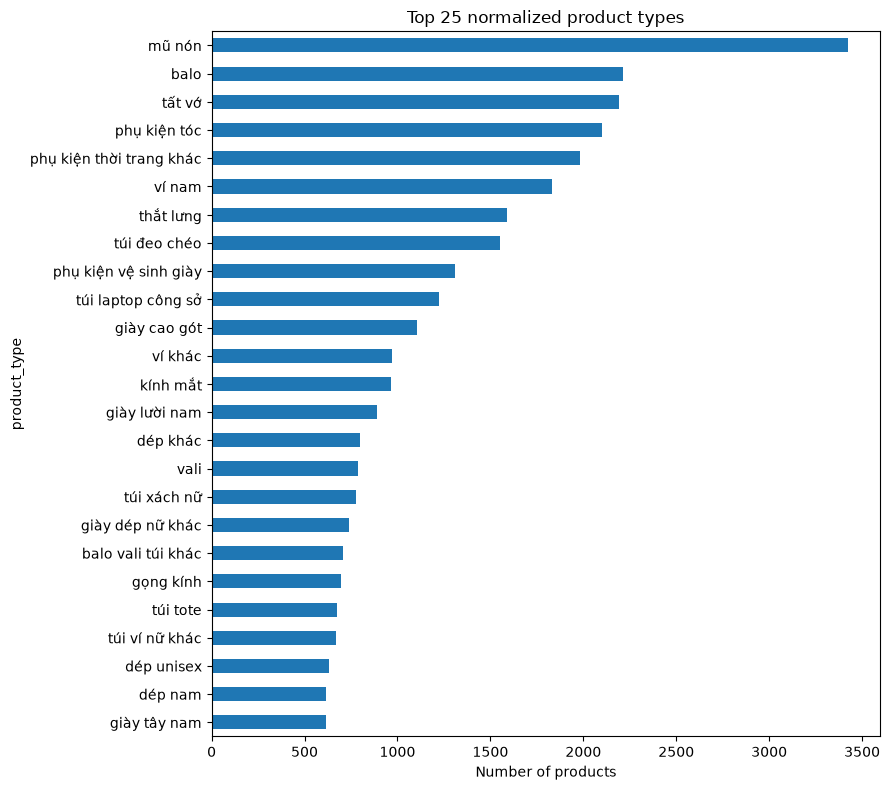

In [8]:
# Top product types by size
ptype_counts = clean['product_type'].fillna('missing').value_counts()
top = ptype_counts.head(25).sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
top.plot(kind='barh', ax=ax)
ax.set_title('Top 25 normalized product types')
ax.set_xlabel('Number of products')
ax.set_ylabel('product_type')
savefig('04_product_type_top_counts.png')

ptype_counts.rename('count').to_csv(FIGURE_DIR / 'product_type_counts.csv')

,rows,fallback_rows,fallback_rate
source_file,,,
vietnamese_tiki_products_women_bags.csv,4324,669,0.154718
vietnamese_tiki_products_backpacks_suitcases.csv,5359,706,0.131741
vietnamese_tiki_products_women_shoes.csv,5917,740,0.125063
vietnamese_tiki_products_fashion_accessories.csv,16005,1913,0.119525
vietnamese_tiki_products_men_shoes.csv,5744,593,0.103238
vietnamese_tiki_products_men_bags.csv,4227,206,0.048734


saved -> ml/artifacts/eda/05_fallback_rate_by_source_file.png


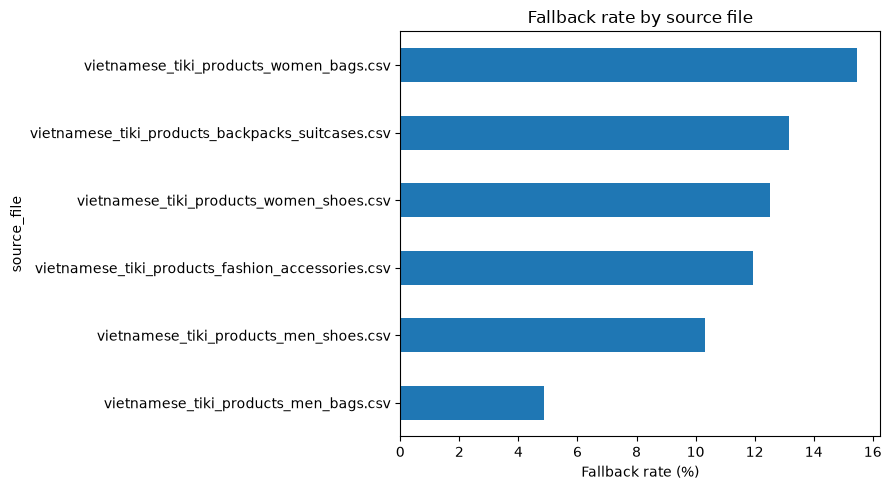

In [9]:
# Fallback rate by source file (để biết raw source nào taxonomy còn yếu)
fallback_flag = clean['taxonomy_source'].eq('source_fallback')
if 'source_file' in clean.columns:
    by_source = (clean.assign(is_fallback=fallback_flag)
                 .groupby('source_file')
                 .agg(rows=('product_id','size'), fallback_rows=('is_fallback','sum'), fallback_rate=('is_fallback','mean'))
                 .sort_values('fallback_rate', ascending=False))
    display(by_source)
    fig, ax = plt.subplots(figsize=(9, 5))
    (by_source['fallback_rate']*100).sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Fallback rate by source file')
    ax.set_xlabel('Fallback rate (%)')
    ax.set_ylabel('source_file')
    savefig('05_fallback_rate_by_source_file.png')
    by_source.to_csv(FIGURE_DIR / 'fallback_rate_by_source_file.csv')
else:
    print('[skip] source_file không có trong clean_products.csv')

,rows,fallback_rows,fallback_rate
product_type,,,
giày dép nữ khác,740,740,1.000000
balo vali túi khác,706,706,1.000000
túi ví nữ khác,669,669,1.000000
giày dép nam khác,593,593,1.000000
túi ví nam khác,206,206,1.000000
phụ kiện thời trang khác,1984,1913,0.964214
mũ nón,3425,0,0.000000
balo,2212,0,0.000000
tất vớ,2193,0,0.000000


saved -> ml/artifacts/eda/06_fallback_rate_by_product_type.png


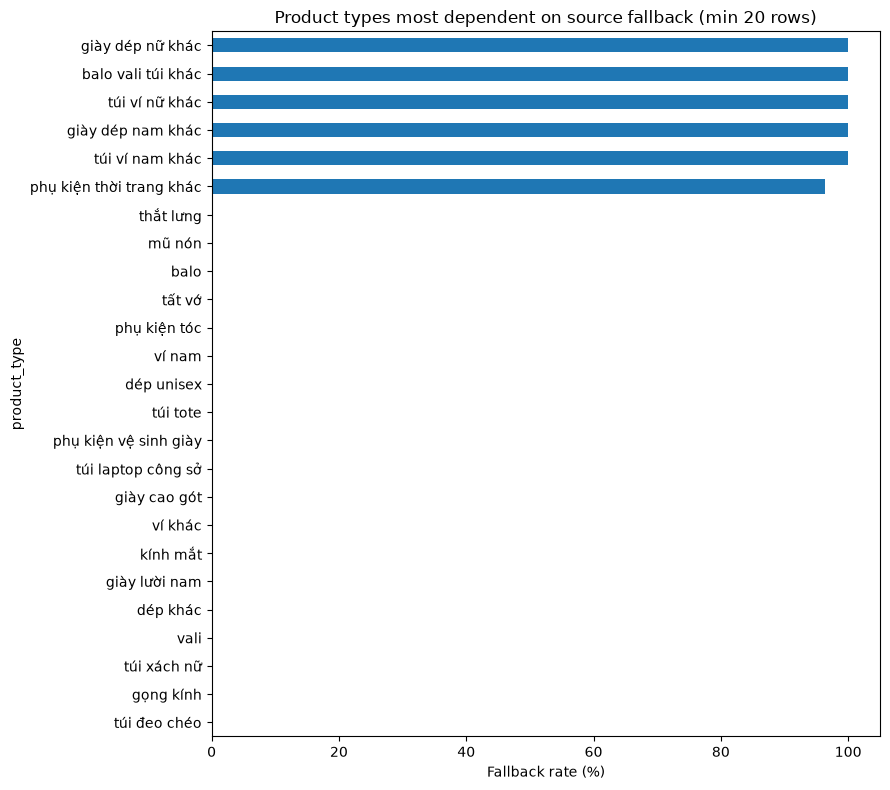

In [10]:
# Fallback dependence by current output product type
by_ptype = (clean.assign(is_fallback=fallback_flag)
            .groupby('product_type')
            .agg(rows=('product_id','size'), fallback_rows=('is_fallback','sum'), fallback_rate=('is_fallback','mean')))
by_ptype = by_ptype[by_ptype['rows'] >= 20].sort_values(['fallback_rate','rows'], ascending=[False,False])
display(by_ptype.head(30))

plot_data = by_ptype.head(25).sort_values('fallback_rate')
fig, ax = plt.subplots(figsize=(9, 8))
(plot_data['fallback_rate']*100).plot(kind='barh', ax=ax)
ax.set_title('Product types most dependent on source fallback (min 20 rows)')
ax.set_xlabel('Fallback rate (%)')
ax.set_ylabel('product_type')
savefig('06_fallback_rate_by_product_type.png')
by_ptype.to_csv(FIGURE_DIR / 'fallback_rate_by_product_type.csv')

# 5. Independent taxonomy holdout — chỉ chạy sau khi review hoàn thành

Notebook sẽ tự merge:

- `taxonomy_holdout_review.csv` — human label
- `taxonomy_holdout_predictions_private.csv` — prediction đã giấu trong lúc review

**Không dùng kết quả holdout để sửa `taxonomy.yml` trước khi chốt accuracy cuối.** Sau khi ghi nhận metric độc lập rồi mới dùng error analysis để lên kế hoạch vòng tiếp theo.

In [11]:
holdout_review = read_csv_if_exists(REVIEW_DIR / 'taxonomy_holdout_review.csv', dtype=str)
holdout_pred = read_csv_if_exists(REVIEW_DIR / 'taxonomy_holdout_predictions_private.csv', dtype=str)
holdout_eval = None

if holdout_review is not None and holdout_pred is not None:
    holdout_review = holdout_review.fillna('')
    holdout_pred = holdout_pred.fillna('')
    holdout_eval = holdout_review.merge(holdout_pred, on='product_id', how='left', validate='one_to_one')
    holdout_eval['human_product_type'] = holdout_eval['human_product_type'].str.strip()
    holdout_eval['review_complete'] = holdout_eval['human_product_type'].ne('')
    completed = holdout_eval.loc[holdout_eval['review_complete']].copy()
    if len(completed):
        completed['correct'] = completed['human_product_type'].eq(completed['predicted_product_type'])
        print('Holdout completed:', len(completed), '/', len(holdout_eval))
        print('Holdout accuracy:', pct(completed['correct'].mean()))
        display(completed.groupby('taxonomy_source')['correct'].agg(['count','mean']).sort_values('mean'))
    else:
        print('Holdout file có nhưng chưa có human_product_type. Review xong rồi chạy lại notebook.')
else:
    print('Chưa có holdout review files. Có thể tạo bằng: python3 -m ml.src.cli create-review-queues')

Holdout completed: 300 / 300
Holdout accuracy: 50.33%


,count,mean
taxonomy_source,,
source_fallback,100,0.020000
category_rule,76,0.657895
name_priority_rule,39,0.794872
name_rule,85,0.800000


saved -> ml/artifacts/eda/10_holdout_accuracy_by_source.png


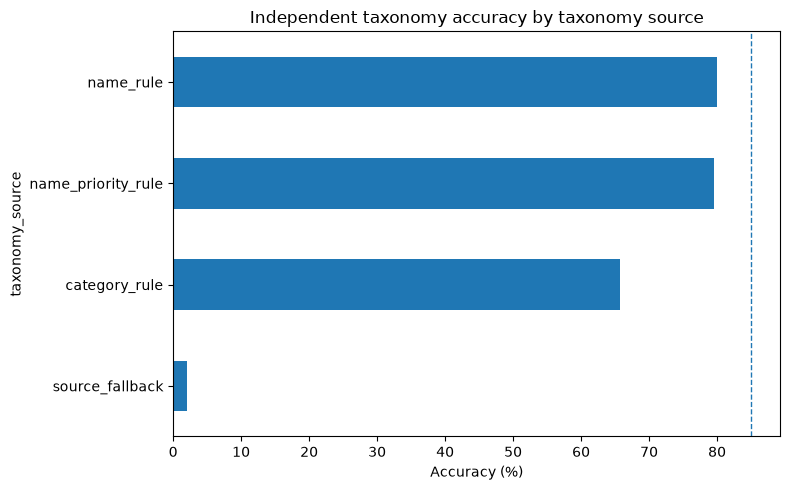

In [12]:
if holdout_eval is not None:
    completed = holdout_eval.loc[holdout_eval['review_complete']].copy()
    if len(completed):
        completed['correct'] = completed['human_product_type'].eq(completed['predicted_product_type'])
        by_holdout_source = completed.groupby('taxonomy_source')['correct'].agg(['count','mean']).sort_values('mean')
        fig, ax = plt.subplots(figsize=(8, 5))
        (by_holdout_source['mean']*100).plot(kind='barh', ax=ax)
        ax.set_title('Independent taxonomy accuracy by taxonomy source')
        ax.set_xlabel('Accuracy (%)')
        ax.set_ylabel('taxonomy_source')
        ax.axvline(85, linestyle='--', linewidth=1)
        savefig('10_holdout_accuracy_by_source.png')
        by_holdout_source.to_csv(FIGURE_DIR / 'holdout_accuracy_by_source.csv')

,count,mean
predicted_product_type,,
giày dép nam khác,17,0.000000
giày dép nữ khác,17,0.000000
túi ví nữ khác,17,0.000000
balo vali túi khác,16,0.000000
túi ví nam khác,16,0.000000
phụ kiện thời trang khác,22,0.227273
dép khác,4,0.250000
giày nữ,4,0.250000
túi laptop công sở,4,0.250000


saved -> ml/artifacts/eda/11_holdout_accuracy_by_product_type.png


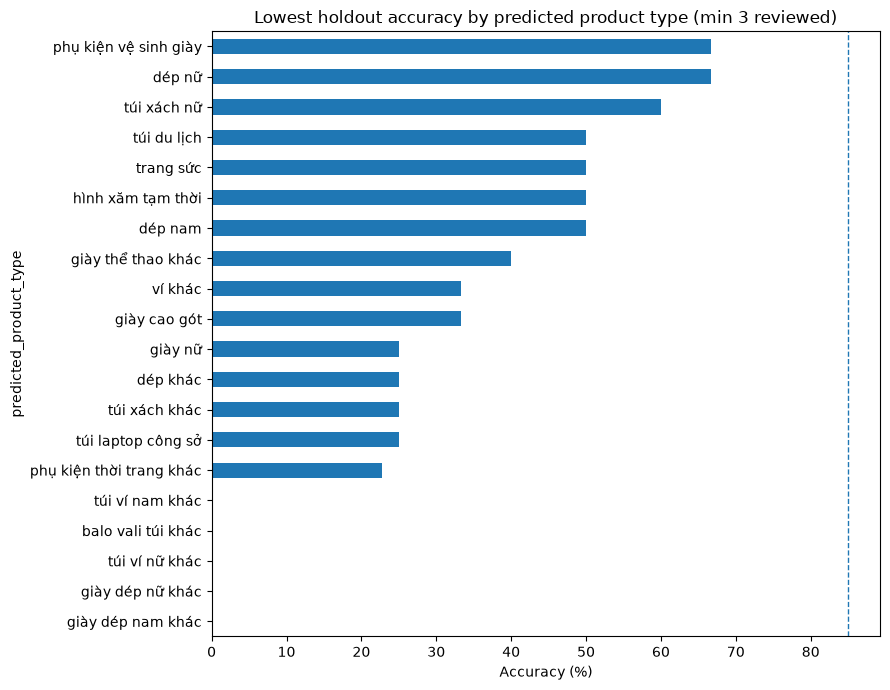

,product_id,product_name,category_raw,predicted_product_type,human_product_type,taxonomy_source,taxonomy_match
1,196941199,"Dép Hương Quế Đi Trong Nhà Hương Quế Trà Bồng, Tạo Cảm Giác Nhẹ Nhàng Thoải Mái Khi Mang - Hàng Chính Hãng",Dép - Guốc nữ,dép nữ,dép unisex,category_rule,dép - guốc nữ
4,187610780,Giày nam boot 12.DESTINY mẫu chiến binh chất liệu da nhập khẩu cao cấp màu đen,Root,giày nam,boots nam,name_rule,giày nam
6,208632099,MTS1H -18x16cm - COMBO 25 TÚI GÓI HÀNG CHỐNG SỐC BỌC BÓNG KHÍ MÀU HỒNG PASTEL,Túi chống sốc,túi laptop công sở,out_of_scope,category_rule,túi chống sốc
12,195465137,Cặp Đệm Silicon Tách Ngón Chân Cấu TrúcTổ Ong Bàn Chân Trước #sil72,Root,giày dép nữ khác,out_of_scope,source_fallback,women_shoes
14,207419440,"Túi đựng mỹ phẩm, túi đựng đồ du lịch bằng nhựa PVC trong suốt hoạ tiết gấu hoạt hình",Root,balo vali túi khác,phụ kiện vali du lịch,source_fallback,backpacks_suitcases
15,169363887,Giày sục nữ đi mưa mũi tròn cao 2p V293,Giày búp bê mũi tròn,giày búp bê,giày lười nữ,category_rule,giày búp bê
19,179912040,Dây Giày Tròn Thể Thao Nhiều Màu Tiết Kiệm Thời Gian DG02,Root,giày dép nữ khác,phụ kiện vệ sinh giày,source_fallback,women_shoes
26,199103385,Cath Kidston - Túi đựng mỹ phẩm/Zip Cosmetic Bag - Pomegranate - Cream -1049602,Root,balo vali túi khác,ambiguous,source_fallback,backpacks_suitcases
28,155773895,Hũ 10g 15g chiết mỹ phẩm kem,Root,balo vali túi khác,out_of_scope,source_fallback,backpacks_suitcases
32,221253129,Mũ hấp dầu tóc tại nhà,Root,mũ nón,out_of_scope,name_rule,mũ


In [13]:
if holdout_eval is not None:
    completed = holdout_eval.loc[holdout_eval['review_complete']].copy()
    if len(completed):
        completed['correct'] = completed['human_product_type'].eq(completed['predicted_product_type'])
        by_pred = completed.groupby('predicted_product_type')['correct'].agg(['count','mean'])
        by_pred = by_pred[by_pred['count'] >= 3].sort_values(['mean','count'], ascending=[True,False])
        display(by_pred.head(25))
        if len(by_pred):
            plot = by_pred.head(20).sort_values('mean')
            fig, ax = plt.subplots(figsize=(9, 7))
            (plot['mean']*100).plot(kind='barh', ax=ax)
            ax.set_title('Lowest holdout accuracy by predicted product type (min 3 reviewed)')
            ax.set_xlabel('Accuracy (%)')
            ax.set_ylabel('predicted_product_type')
            ax.axvline(85, linestyle='--', linewidth=1)
            savefig('11_holdout_accuracy_by_product_type.png')
        by_pred.to_csv(FIGURE_DIR / 'holdout_accuracy_by_product_type.csv')

        errors = completed.loc[~completed['correct'], [
            c for c in ['product_id','product_name','category_raw','predicted_product_type','human_product_type','taxonomy_source','taxonomy_match']
            if c in completed.columns
        ]]
        errors.to_csv(FIGURE_DIR / 'taxonomy_holdout_errors.csv', index=False)
        display(errors.head(30))

In [14]:
# Confusion pairs — thường hữu ích hơn confusion matrix lớn 50+ nhãn
if holdout_eval is not None:
    completed = holdout_eval.loc[holdout_eval['review_complete']].copy()
    if len(completed):
        completed['correct'] = completed['human_product_type'].eq(completed['predicted_product_type'])
        conf_pairs = (completed.loc[~completed['correct']]
                      .groupby(['predicted_product_type','human_product_type'])
                      .size().rename('count').reset_index()
                      .sort_values('count', ascending=False))
        display(conf_pairs.head(25))
        conf_pairs.to_csv(FIGURE_DIR / 'taxonomy_top_confusion_pairs.csv', index=False)

,predicted_product_type,human_product_type,count
1,balo vali túi khác,out_of_scope,8
23,giày dép nữ khác,phụ kiện vệ sinh giày,6
18,giày dép nam khác,phụ kiện vệ sinh giày,5
65,túi ví nữ khác,out_of_scope,5
24,giày dép nữ khác,sandal nữ,4
20,giày dép nữ khác,ambiguous,4
17,giày dép nam khác,giày nam,4
16,giày dép nam khác,giày lười nam,4
59,túi ví nam khác,túi laptop công sở,4
57,túi ví nam khác,out_of_scope,4


# 6. Fresh sales EDA by normalized product type

Đây là phần nên dùng thay cho các biểu đồ `raw category` cũ. Mục tiêu là kiểm tra xem các nhóm normalized product type có baseline sales khác nhau đáng kể hay không.

In [15]:
ptype_sales = (clean.groupby('product_type')
               .agg(
                   products=('product_id','size'),
                   zero_sales_rate=('quantity_sold', lambda s: pd.to_numeric(s, errors='coerce').fillna(0).eq(0).mean()),
                   median_sales=('quantity_sold','median'),
                   mean_sales=('quantity_sold','mean'),
               )
               .sort_values('products', ascending=False))
ptype_sales.to_csv(FIGURE_DIR / 'sales_by_product_type.csv')
display(ptype_sales.head(30))

,products,zero_sales_rate,median_sales,mean_sales
product_type,,,,
mũ nón,3425,0.530803,0.0,6.209927
balo,2212,0.460669,1.0,21.872966
tất vớ,2193,0.557228,0.0,20.029640
phụ kiện tóc,2103,0.419876,1.0,27.867808
phụ kiện thời trang khác,1984,0.589214,0.0,12.496472
ví nam,1834,0.641767,0.0,10.235005
thắt lưng,1587,0.581601,0.0,12.021424
túi đeo chéo,1552,0.499356,1.0,52.967139
phụ kiện vệ sinh giày,1312,0.312500,4.0,44.695884


saved -> ml/artifacts/eda/07_zero_sales_rate_by_product_type.png


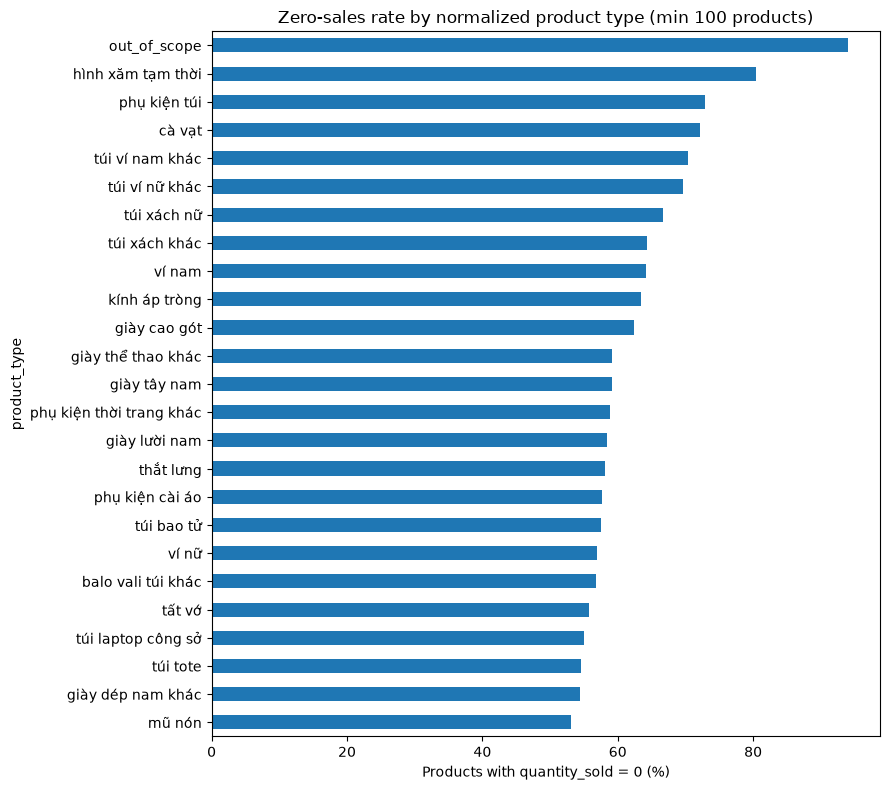

In [16]:
plot = ptype_sales[ptype_sales['products'] >= 100].sort_values('zero_sales_rate', ascending=False).head(25).sort_values('zero_sales_rate')
fig, ax = plt.subplots(figsize=(9, 8))
(plot['zero_sales_rate']*100).plot(kind='barh', ax=ax)
ax.set_title('Zero-sales rate by normalized product type (min 100 products)')
ax.set_xlabel('Products with quantity_sold = 0 (%)')
ax.set_ylabel('product_type')
savefig('07_zero_sales_rate_by_product_type.png')

saved -> ml/artifacts/eda/08_median_sales_by_product_type.png


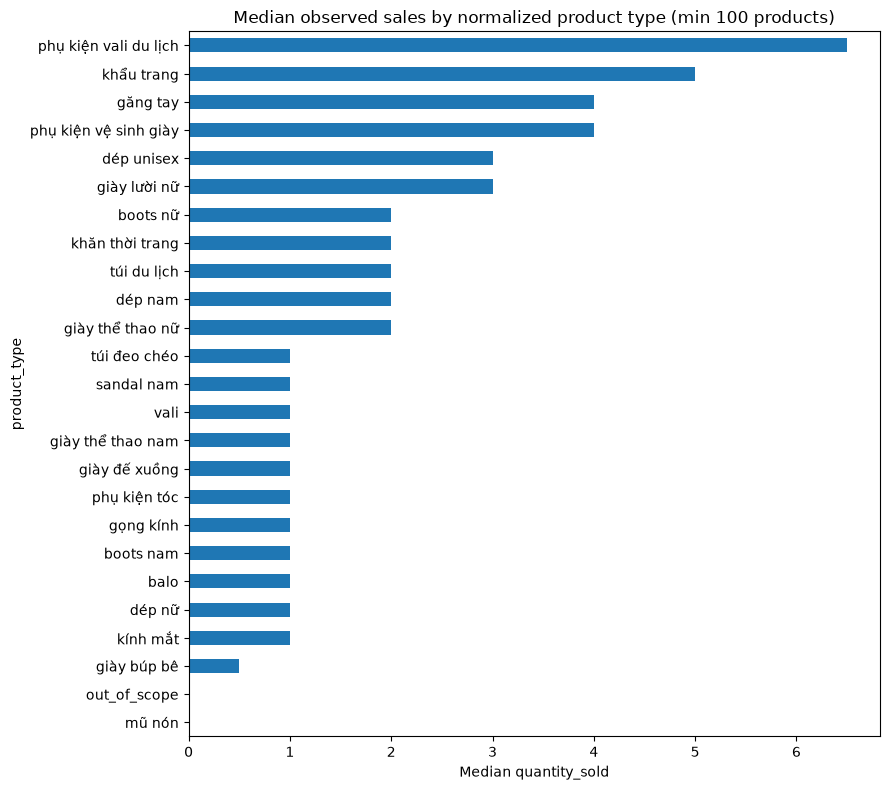

In [17]:
plot = ptype_sales[ptype_sales['products'] >= 100].sort_values('median_sales', ascending=False).head(25).sort_values('median_sales')
fig, ax = plt.subplots(figsize=(9, 8))
plot['median_sales'].plot(kind='barh', ax=ax)
ax.set_title('Median observed sales by normalized product type (min 100 products)')
ax.set_xlabel('Median quantity_sold')
ax.set_ylabel('product_type')
savefig('08_median_sales_by_product_type.png')

# 7. Peer-group quality audit

Taxonomy chỉ có giá trị nếu nó giúp tạo nhóm so sánh hợp lý. Vì vậy cần kiểm tra đồng thời:

- `peer_count`
- `mean_peer_similarity`
- `peer_quality_reason`
- tỷ lệ insufficient data theo product type

Các chart này trực tiếp trả lời: **taxonomy/peer design có đủ tốt để dùng làm reference sales hay chưa?**

saved -> ml/artifacts/eda/09_peer_similarity_distribution.png


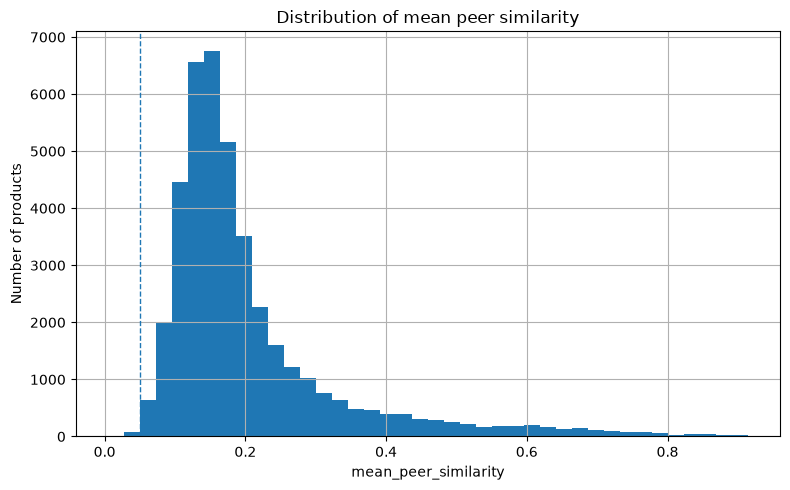

In [18]:
if peer is not None:
    peer['mean_peer_similarity'] = pd.to_numeric(peer['mean_peer_similarity'], errors='coerce')
    peer['peer_count'] = pd.to_numeric(peer['peer_count'], errors='coerce')

    fig, ax = plt.subplots(figsize=(8, 5))
    peer['mean_peer_similarity'].dropna().hist(bins=40, ax=ax)
    ax.set_title('Distribution of mean peer similarity')
    ax.set_xlabel('mean_peer_similarity')
    ax.set_ylabel('Number of products')
    ax.axvline(pipe_cfg.get('minimum_mean_peer_similarity', 0.05), linestyle='--', linewidth=1)
    savefig('09_peer_similarity_distribution.png')
else:
    print('Chưa có peer_features.csv — chạy python3 -m ml.src.cli peers')

saved -> ml/artifacts/eda/12_peer_quality_reason_counts.png


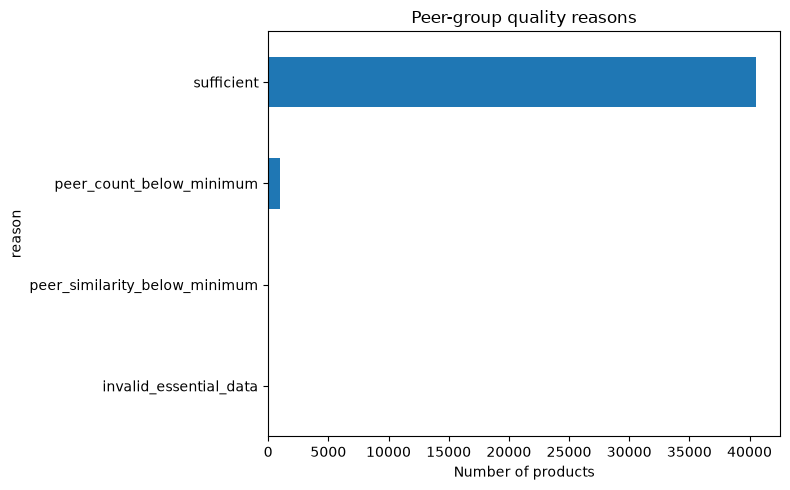

In [19]:
if peer is not None:
    reason = peer['peer_quality_reason'].fillna('').replace('', 'sufficient')
    reason_counts = reason.value_counts()
    fig, ax = plt.subplots(figsize=(8, 5))
    reason_counts.sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Peer-group quality reasons')
    ax.set_xlabel('Number of products')
    ax.set_ylabel('reason')
    savefig('12_peer_quality_reason_counts.png')
    reason_counts.to_csv(FIGURE_DIR / 'peer_quality_reason_counts.csv', header=['count'])

saved -> ml/artifacts/eda/13_insufficient_peer_rate_by_product_type.png


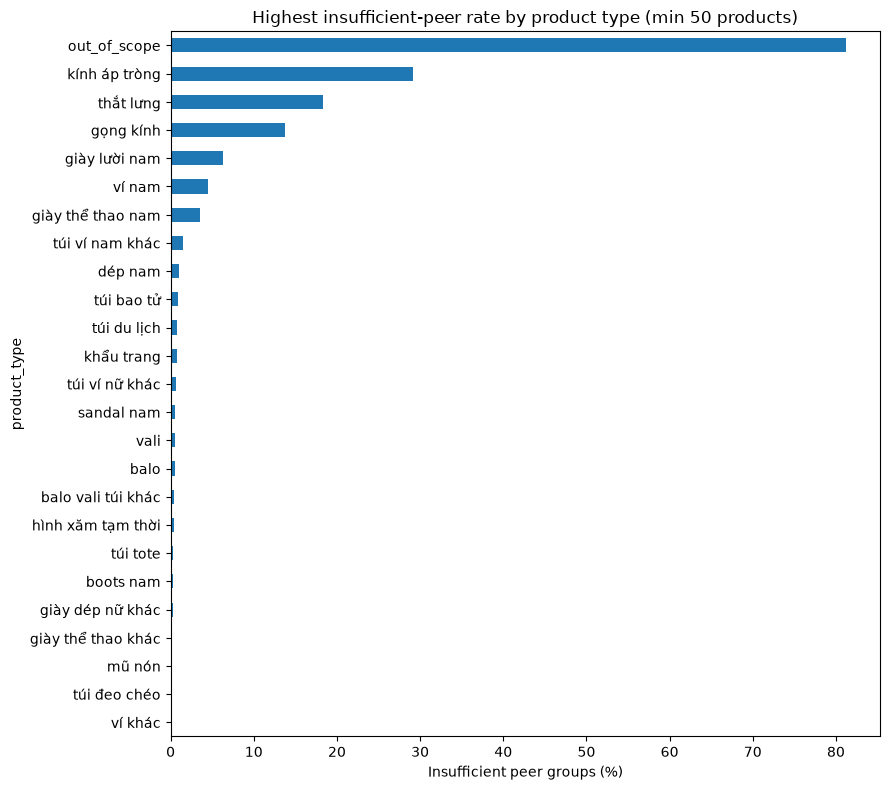

,products,insufficient_rate,median_similarity,median_peer_count
product_type,,,,
đồng hồ,5,1.000000,0.410894,4.0
out_of_scope,453,0.812362,0.086083,0.0
kính áp tròng,309,0.291262,0.110440,25.0
thắt lưng,1587,0.182735,0.193010,25.0
gọng kính,697,0.137733,0.169341,25.0
giày lười nam,888,0.063063,0.190181,25.0
ví nam,1834,0.044711,0.181809,25.0
giày thể thao nam,503,0.035785,0.160301,25.0
túi ví nam khác,206,0.014563,0.142845,25.0


In [20]:
if peer is not None:
    insufficient = peer.get('insufficient_data', False)
    if not isinstance(insufficient, pd.Series):
        insufficient = pd.Series(False, index=peer.index)
    else:
        insufficient = safe_bool(insufficient)
    peer_type_quality = (peer.assign(_insufficient=insufficient)
                         .groupby('product_type')
                         .agg(
                             products=('product_id','size'),
                             insufficient_rate=('_insufficient','mean'),
                             median_similarity=('mean_peer_similarity','median'),
                             median_peer_count=('peer_count','median')
                         ))
    peer_type_quality.to_csv(FIGURE_DIR / 'peer_quality_by_product_type.csv')
    plot = peer_type_quality[peer_type_quality['products']>=50].sort_values('insufficient_rate', ascending=False).head(25).sort_values('insufficient_rate')
    fig, ax = plt.subplots(figsize=(9, 8))
    (plot['insufficient_rate']*100).plot(kind='barh', ax=ax)
    ax.set_title('Highest insufficient-peer rate by product type (min 50 products)')
    ax.set_xlabel('Insufficient peer groups (%)')
    ax.set_ylabel('product_type')
    savefig('13_insufficient_peer_rate_by_product_type.png')
    display(peer_type_quality.sort_values('insufficient_rate', ascending=False).head(25))

# 8. Manual peer review — nếu review đã hoàn thành

Repo tạo peer review theo ba band similarity (`low`, `medium`, `high`). Đây là chart quan trọng để biết threshold hiện tại có khiến low-similarity peers bị “collapse” về chất lượng hay không.

,count,mean
similarity_band,,
low,90,0.577778
medium,60,0.783333
high,100,0.950000


saved -> ml/artifacts/eda/14_peer_review_relevance_by_similarity_band.png


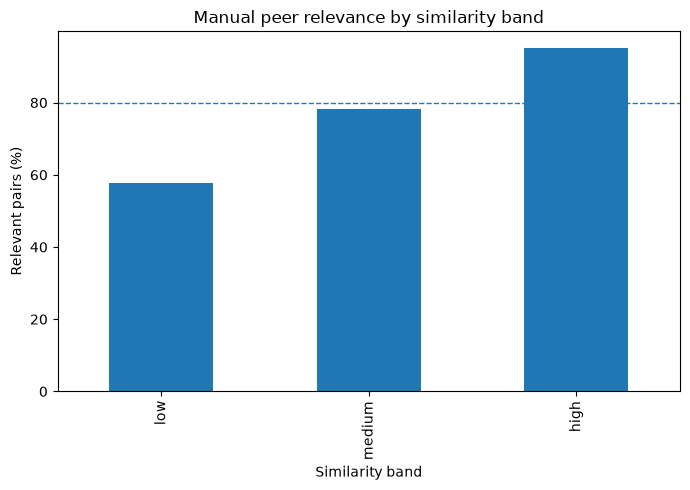

In [21]:
peer_review = read_csv_if_exists(REVIEW_DIR / 'peer_pairs_review.csv', dtype=str)
if peer_review is not None:
    peer_review = peer_review.fillna('')
    valid = peer_review['is_relevant'].str.strip().str.lower().isin({'đúng','sai','true','false','yes','no','1','0'})
    done = peer_review.loc[valid].copy()
    if len(done):
        done['relevant'] = done['is_relevant'].str.strip().str.lower().isin({'đúng','true','yes','1'})
        rel_by_band = done.groupby('similarity_band')['relevant'].agg(['count','mean']).reindex(['low','medium','high'])
        display(rel_by_band)
        fig, ax = plt.subplots(figsize=(7, 5))
        (rel_by_band['mean']*100).plot(kind='bar', ax=ax)
        ax.set_title('Manual peer relevance by similarity band')
        ax.set_ylabel('Relevant pairs (%)')
        ax.set_xlabel('Similarity band')
        ax.axhline(80, linestyle='--', linewidth=1)
        savefig('14_peer_review_relevance_by_similarity_band.png')
        rel_by_band.to_csv(FIGURE_DIR / 'peer_review_relevance_by_similarity_band.csv')
    else:
        print('Peer review queue có nhưng chưa được annotate.')

# 9. Listing-content EDA: image count & video

Các biến này là actionable-ish listing attributes, nên có thể dùng để mô tả pattern và hỗ trợ recommendation hypotheses. **Không kết luận “thêm ảnh/video sẽ làm sales tăng”.**

,count,median,mean
image_bin,,,
0-1,4034,0.0,19.501239
2-3,6200,0.0,22.743226
4-5,9421,0.0,13.831228
6-7,8458,0.0,15.989123
8-10,11636,0.0,15.202131
11+,1827,3.0,42.137931


saved -> ml/artifacts/eda/15_image_count_vs_median_sales.png


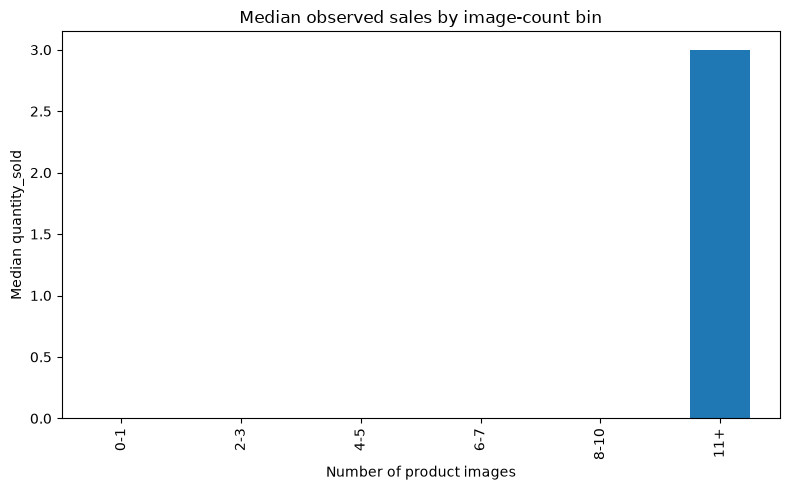

In [22]:
# image_count bins vs observed sales
if 'image_count' in clean.columns:
    tmp = clean[['image_count','quantity_sold']].copy()
    tmp['image_count'] = pd.to_numeric(tmp['image_count'], errors='coerce')
    tmp['quantity_sold'] = pd.to_numeric(tmp['quantity_sold'], errors='coerce')
    tmp = tmp.dropna()
    bins = [-np.inf, 1, 3, 5, 7, 10, np.inf]
    labels = ['0-1','2-3','4-5','6-7','8-10','11+']
    tmp['image_bin'] = pd.cut(tmp['image_count'], bins=bins, labels=labels)
    img_stats = tmp.groupby('image_bin', observed=False)['quantity_sold'].agg(['count','median','mean'])
    display(img_stats)
    fig, ax = plt.subplots(figsize=(8,5))
    img_stats['median'].plot(kind='bar', ax=ax)
    ax.set_title('Median observed sales by image-count bin')
    ax.set_xlabel('Number of product images')
    ax.set_ylabel('Median quantity_sold')
    savefig('15_image_count_vs_median_sales.png')
    img_stats.to_csv(FIGURE_DIR / 'image_count_sales_stats.csv')

,count,median,mean
has_video_bool,,,
False,37305,0.0,15.882831
True,4271,3.0,34.321002


saved -> ml/artifacts/eda/16_video_vs_median_sales.png


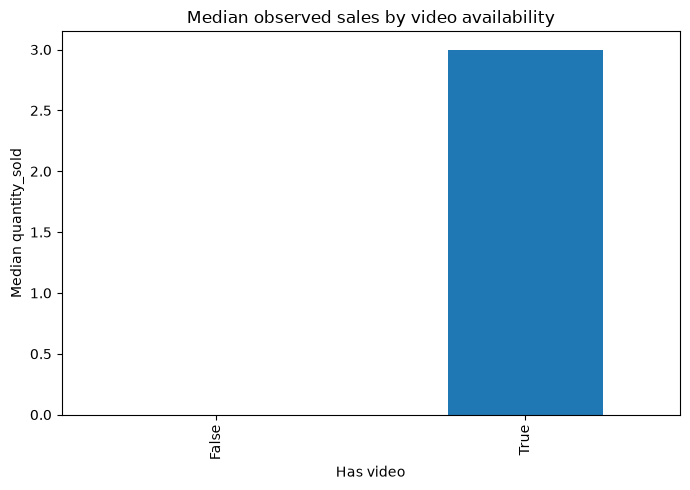

In [23]:
if 'has_video' in clean.columns:
    tmp = clean[['has_video','quantity_sold']].copy()
    tmp['has_video_bool'] = safe_bool(tmp['has_video'])
    video_stats = tmp.groupby('has_video_bool')['quantity_sold'].agg(['count','median','mean'])
    display(video_stats)
    fig, ax = plt.subplots(figsize=(7,5))
    video_stats['median'].plot(kind='bar', ax=ax)
    ax.set_title('Median observed sales by video availability')
    ax.set_xlabel('Has video')
    ax.set_ylabel('Median quantity_sold')
    savefig('16_video_vs_median_sales.png')
    video_stats.to_csv(FIGURE_DIR / 'video_sales_stats.csv')

# 10. Automatic audit summary

Cell cuối gom các số quan trọng để sau khi Nhung gửi lại notebook/output, có thể viết report ngắn mà không phải đọc từng chart thủ công.

In [24]:
summary = {
    **snapshot,
    **concentration,
    'taxonomy': {
        'explicit_rule_labels': len(set(rule_labels)),
        'unique_fallback_labels': len(set(fallback_labels)),
        'possible_output_labels_union': len(set(rule_labels)|set(fallback_labels)),
        'observed_labels': len(observed_labels),
        'fallback_only_labels': sorted(set(fallback_labels)-set(rule_labels)),
        'fallback_rate': float(clean['taxonomy_source'].eq('source_fallback').mean()),
        'taxonomy_source_counts': clean['taxonomy_source'].value_counts().to_dict(),
    },
    'peer_config': {
        'peer_count': pipe_cfg.get('peer_count'),
        'minimum_peer_count': pipe_cfg.get('minimum_peer_count'),
        'minimum_mean_peer_similarity': pipe_cfg.get('minimum_mean_peer_similarity'),
    },
}

if holdout_eval is not None:
    completed = holdout_eval.loc[holdout_eval['review_complete']].copy()
    if len(completed):
        completed['correct'] = completed['human_product_type'].eq(completed['predicted_product_type'])
        summary['independent_taxonomy_holdout'] = {
            'completed_rows': int(len(completed)),
            'total_rows': int(len(holdout_eval)),
            'accuracy': float(completed['correct'].mean()),
        }

if peer is not None:
    insufficient = safe_bool(peer['insufficient_data']) if 'insufficient_data' in peer else pd.Series(False, index=peer.index)
    summary['peers'] = {
        'rows': int(len(peer)),
        'sufficient_rows': int((~insufficient).sum()),
        'insufficient_rows': int(insufficient.sum()),
        'median_mean_peer_similarity': float(pd.to_numeric(peer['mean_peer_similarity'], errors='coerce').median()),
    }

if peer_review is not None:
    valid = peer_review['is_relevant'].fillna('').str.strip().str.lower().isin({'đúng','sai','true','false','yes','no','1','0'})
    done = peer_review.loc[valid].copy()
    if len(done):
        done['relevant'] = done['is_relevant'].str.strip().str.lower().isin({'đúng','true','yes','1'})
        summary['peer_manual_review'] = {
            'completed_pairs': int(len(done)),
            'overall_relevance': float(done['relevant'].mean()),
            'by_similarity_band': done.groupby('similarity_band')['relevant'].mean().to_dict(),
        }

out = FIGURE_DIR / 'eda_audit_summary.json'
out.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved ->', out.relative_to(ROOT))
print(json.dumps(summary, ensure_ascii=False, indent=2)[:8000])

saved -> ml/artifacts/eda/eda_audit_summary.json
{
  "clean_rows": 41576,
  "unique_product_ids": 41576,
  "seller_count": 3807,
  "product_type_count_observed": 58,
  "raw_category_count": 155,
  "valid_for_model_rows": 41575,
  "zero_sales_rate": 0.5182797767943044,
  "median_sales": 0.0,
  "mean_sales": 17.77693861843371,
  "max_sales": 24847.0,
  "top_1pct_sales_share": 0.4782977537363312,
  "top_5pct_sales_share": 0.76428708662227,
  "top_10pct_sales_share": 0.8764040839189602,
  "top_20pct_sales_share": 0.9568309308423556,
  "taxonomy": {
    "explicit_rule_labels": 53,
    "unique_fallback_labels": 6,
    "possible_output_labels_union": 58,
    "observed_labels": 58,
    "fallback_only_labels": [
      "balo vali túi khác",
      "giày dép nam khác",
      "giày dép nữ khác",
      "túi ví nam khác",
      "túi ví nữ khác"
    ],
    "fallback_rate": 0.11610063498172023,
    "taxonomy_source_counts": {
      "category_rule": 16703,
      "name_rule": 14077,
      "name_priority_

# 11. Cách kết luận task sau khi chạy xong

Đừng chỉ ghi “đã EDA”. Hãy chốt theo 4 nhóm evidence:

### A. Data shape
- Clean rows / valid rows.
- Zero-sales rate, median và concentration.
- Kết luận có/không đủ justification cho contextual reference sales.

### B. Taxonomy
- Rule coverage vs fallback rate.
- Product types nào fallback-heavy.
- Independent holdout accuracy (nếu đã hoàn thành).
- Các confusion/error pattern chính.
- Definition rõ ràng của số lượng taxonomy labels.

### C. Peers
- Bao nhiêu sản phẩm đủ peer.
- Distribution mean similarity.
- Product types nào thiếu peer nhiều.
- Manual peer relevance overall + low/medium/high band.

### D. Actionable listing signals
- Ảnh/video chỉ báo cáo **association mô tả**.
- Không viết causal claim.
- Chỉ dùng những pattern này như evidence để hình thành recommendation hypothesis.

### Expected next action
- Nếu holdout taxonomy < 85%: ưu tiên taxonomy error analysis + fallback-development queue.
- Nếu peer relevance < 80% hoặc low band collapse: xem lại threshold / text representation / rules trước khi dựa vào peer evidence trong demo.
- Nếu cả taxonomy và peer pass: mới xem đây là nền đủ ổn để chốt dashboard/report.